# Transition curve experiments for lifted auto-calibrated pMRI

This notebook contains small-scale synthetic experiments (e.g., Figs. 2-7) for the lifted sparse recovery problem used in the paper:

**Y. Ni & T. Strohmer, “Auto-Calibration and Biconvex Compressive Sensing with Applications to Parallel MRI.”**

These experiments use CVXPY to directly solve the lifted convex recovery problem. The specific optimizer/backend is determined by the `prob.solve(...)` call in the code. The custom iterative FISTA-style solver is not used here; it is used for larger image reconstruction experiments, for example in `lsense.m` and the real-data reconstruction scripts.

The notebook is provided as an archived experiment record. Some result arrays are stored directly in the notebook to avoid rerunning expensive CVXPY solves.

This notebook studies a lifted sparse recovery formulation for the bilinear inverse problem

$$
y = A \operatorname{diag}(Bh)x, \qquad x = \Phi^{-1}z,
$$

where both the calibration parameter $h$ and the signal $x$ are unknown. The vector $h$ parameterizes the unknown coil/sensitivity model, while $z$ is sparse in a known transform basis $\Phi$.

By lifting the bilinear unknowns into

$$
Z = h z^T,
$$

the measurements can be written as a linear function of $Z$. In these small-scale synthetic experiments, the lifted optimization problem is solved directly using CVXPY instead of a custom iterative solver. For the custom iterative solver used in larger real-data reconstruction problems, see `lsense.m` and the real-data reconstruction scripts.

$\textbf{Inputs}$

- $A \in \mathbb{R}^{L \times N}$ or $\mathbb{C}^{L \times N}$: sensing matrix. Each row is sampled without replacement from an $N$-point DFT matrix.
- $B \in \mathbb{C}^{N \times k}$: calibration subspace matrix, chosen as the first $k$ columns of an $N \times N$ unitary DFT matrix, an random ONB or as a polynomial basis.
- $h_0 \in \mathbb{C}^{k}$: ground-truth calibration vector, drawn from one of several test distributions.
- $\Phi$: sparsifying transform, chosen as a random orthonormal basis, DCT basis, DWT basis.
- $z_0 \in \mathbb{C}^{N}$: sparse coefficient vector.
- $x_0 = \Phi^{-1}z_0$: ground-truth signal.
- $Z_0 = h_0 z_0^T \in \mathbb{C}^{k \times N}$: lifted ground-truth matrix.
- $y_0 = A\operatorname{diag}(Bh_0)x_0$: noiseless measurements.
- $PB \in \mathbb{C}^{N \times kN}$: linear operator satisfying
$
PB\,\operatorname{vec}(Z) = \operatorname{diag}(Bh)\Phi^{-1}z.
$

$\textbf{Optimization problem}$

The lifted recovery problem is
$
\min_Z \|Z\|_{1,2}
$,
subject to
$
A\,PB\,\operatorname{vec}(Z) = y_0.
$

Here, $\|Z\|_{1,2}$ promotes structured sparsity in the lifted matrix. In these experiments, the problem is solved using a direct CVXPY formulation.

$\textbf{Success criterion}$

Recovery is considered successful if
$
\frac{\|Z - Z_0\|_F}{\|Z_0\|_F} \leq 0.01.
$

The success rates and experiment data are stored in `succ_exp` and `datasave`.

In [1]:
import numpy as np
import cvxpy as cp
import math
import pywt
from scipy.stats import ortho_group
from scipy.linalg import dft
from scipy.sparse import csc_matrix
from scipy.fftpack import dct
from scipy.signal import cwt

**Solver**

Boundary experiment: measurements L versus sparsity n

L = number of measurements,
n = sparsity level,
k = calibration / sensitivity basis dimension,
C = number of coils

In [ ]:
def solver(k,C,B,Phi):
    for L in range(n_L):
        L = (L+1) * 10
        for n in range(n_z):
            n = n+1
            succ_rate = 0
            for exp in range(n_exp) :
                succ = 0

                #generate data
                #A = np.random.randn(L,N)/L #sampled independently for each exp
                pattern = np.random.choice(N, L,replace=False)
                A = np.asarray([FFT2[i,:] for i in pattern ])

                #Construct the n sparse z_0
                row = np.random.choice(N, n) #choose n rows from [0,N)
                column = np.repeat([0],n)
                data =  np.random.randn(n)
                z_0 = csc_matrix((data, (row,column)), shape=(N, 1)).toarray()

                x_0 = Phi.conj().T@z_0
                h_0 = np.random.randn(k,C)
                h_0 /= np.linalg.norm(h_0,axis=0)
                h_vec = np.reshape(h_0,(-1,1),order='F')
                Z_vec = np.kron(z_0, h_0) #Z_vec have vec(h_ix^T) as columns
                #print(Z_vec.shape)
                B_k = B[:,0:k]
                y_0 = A@((B_k@h_0)*x_0) #get the measurement

                #construct the matrix PB
                PB =  np.zeros((N,k*N),dtype=complex)
                for i in range(N):
                  PB[i,:] = np.kron(Phi[:,i],B_k[i,:].conj().T).conj().T
                P = A @ PB #overall system matrix
                #print('sanity check',np.linalg.norm(P @ Z_vec - y_0))

                #Solving the l1,2 norm optimization problem
                Z = cp.Variable((k*N,C))
                Z_rs = cp.reshape(Z,(N,k*C),order = 'C')
                objective = cp.Minimize(cp.mixed_norm(Z_rs,2,1))
                constraint = [P@Z == y_0]
                #constraint = [cp.norm(A@PB@Z - y_0,2) <= 1e-1] #noisy case
                prob = cp.Problem(objective, constraint)
                prob.solve(solver = cp.MOSEK )

                Z_sol = Z.value
                succ = np.linalg.norm(Z_sol-Z_vec)/np.linalg.norm(Z_vec)

                #criteria for success
                succ_rate += (succ <=0.01)*1; #1 if the relative error is smaller than 1%

            succ_exp[((L-1)//10),n-1] = succ_rate
    return succ_exp


**Plotting**

In [3]:
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as ticker

In [ ]:
C = 1 #number of coils
L = 128 #number of measurement
k = 6
n_x = 16 #image dimension
N = n_x**2 #dimension of x
n_L = 20 #max number of measurement 20
n_z = 15 #max sparsity in z
n_exp = 10 #


B = ortho_group.rvs(N) #ONB used in the paper
#B = dft(N,scale='sqrtn') #such that I_N=np.matmul(B.conj().T,B)
#B = np.kron(np.fft.fft(np.eye(12)),np.fft.fft(np.eye(12))); #hard-coded FFT2

Phi = dct(np.eye(N),norm='ortho') #DCT basis (same as paper)
#Phi = pywt.dwt(np.eye(N),'coif1') #Wavelet casis
#Phi = ortho_group.rvs(N)

succ_exp = np.zeros((n_L,n_z))
datasave=[]

In [12]:
FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))

In [ ]:
succ_exp = solver(k,C,B,Phi)

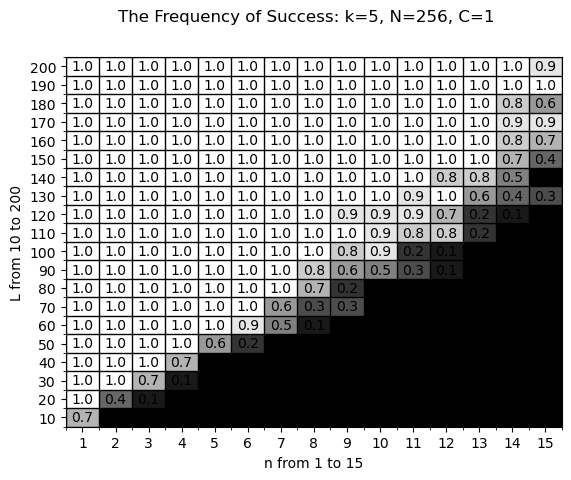

In [16]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_z,1))
ax.set_xticklabels(1+np.arange(0,n_z,1))

ax.set_yticks(np.arange(n_L-0.5, -1, -1), minor=True)
ax.set_yticks(np.arange(n_L-1,-1,-1))
ax.set_yticklabels(np.arange(n_L*10, 0, -10))

ax.set_xlim([-0.5, n_z - 0.5])  # Adjust these values according to your data range
ax.set_ylim([-0.5, n_L - 0.5])  # Adjust these values according to your data range
ax.set_xlabel('n from 1 to 15')
ax.set_ylabel('L from 10 to 200')

plt.imshow(succ_exp, cmap = 'gray',aspect='auto')
for i in range(n_z):
    for j in range(n_L):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')


fig.suptitle(f'The Frequency of Success: k=5, N=256, C={C}')
plt.show()

Increasing the number of coils improves recovery near the transition boundary.

In [ ]:
C = 4 #number of coils
L = 128 #number of measurement
k = 5
n_x = 16 #image dimension
n_L = 20
N = n_x**2 #dimension of x
n_z = 15 #max sparsity in z
n_exp = 10 #repeated experiments to calculate the empirical success rate

B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')

succ_exp = np.zeros((n_L,n_z))
datasave=[]

In [ ]:
succ_exp = solver(k,C,B,Phi)

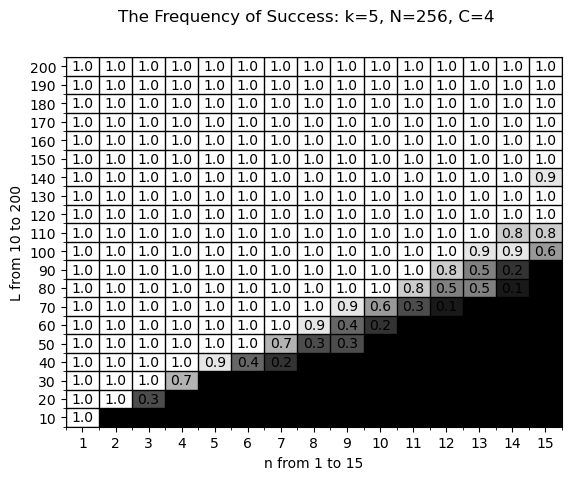

In [10]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_z,1))
ax.set_xticklabels(1+np.arange(0,n_z,1))

ax.set_yticks(np.arange(n_L-0.5, -1, -1), minor=True)
ax.set_yticks(np.arange(n_L-1,-1,-1))
ax.set_yticklabels(np.arange(n_L*10, 0, -10))

ax.set_xlim([-0.5, n_z - 0.5])  # Adjust these values according to your data range
ax.set_ylim([-0.5, n_L - 0.5])  # Adjust these values according to your data range
ax.set_xlabel('n from 1 to 15')
ax.set_ylabel('L from 10 to 200')

plt.imshow(succ_exp, cmap = 'gray',aspect='auto')
for i in range(n_z):
    for j in range(n_L):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')


fig.suptitle(f'The Frequency of Success: k=5, N=256, C={C}')
plt.show()